## 1. Pre-trained Models For ASR
* In this section, we’ll cover how to use the `pipeline()` to leverage pre-trained models for speech recognition.
* Speech recognition model broadly fall into one of two categories:
  1. Connectionist Temporal Classification (CTC): encoder-only models with a linear classification (CTC) head on top.
  2. Sequence-to-sequence (Seq2Seq): encoder-decoder models, with a cross-attention mechanism between the encoder and decoder.

* Prior to 2022, CTC was the more popular of the two architectures, with encoder-only models such as Wav2Vec2, HuBERT and XLSR achieving breakthoughs in the pre-training / fine-tuning paradigm for speech.
* However, CTC models have their shortcomings. Appending a simple linear layer to an encoder gives a small, fast overall model, but can be prone to phonetic spelling errors. We’ll demonstrate this for the Wav2Vec2 model below.

### 1.1 Probing CTC Models

In [3]:
# Load a small excerpt of the LibriSpeech ASR dataset
# to demonstrate Wav2Vec2’s speech transcription capabilities

from datasets import load_dataset

dataset = load_dataset(
    "hf-internal-testing/librispeech_asr_dummy", "clean", split="validation"
)
dataset

Dataset({
    features: ['file', 'audio', 'text', 'speaker_id', 'chapter_id', 'id'],
    num_rows: 73
})

In [13]:
# Inspect one audio sample and its transcription

from IPython.display import Audio

sample = dataset[2]

print(f"Transcription: {sample['text']}")
Audio(sample["audio"]["array"], rate=sample["audio"]["sampling_rate"])

Transcription: HE TELLS US THAT AT THIS FESTIVE SEASON OF THE YEAR WITH CHRISTMAS AND ROAST BEEF LOOMING BEFORE US SIMILES DRAWN FROM EATING AND ITS RESULTS OCCUR MOST READILY TO THE MIND


In [6]:
# Load a fine-tuned Wav2Vec2 base model into the pipeline()

from transformers import pipeline

pipe = pipeline(
    "automatic-speech-recognition",
    model="facebook/wav2vec2-base-100h",
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/358 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/96.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

In [9]:
pipe({"array": sample["audio"]["array"], "sampling_rate": sample["audio"]["sampling_rate"]})


{'text': 'HE TELLS US THAT AT THIS FESTIVE SEASON OF THE YEAR WITH CHRISTMAUS AND ROSE BEEF LOOMING BEFORE US SIMALYIS DRAWN FROM EATING AND ITS RESULTS OCCUR MOST READILY TO THE MIND'}

* Compare the result with truth label:

  **Target:**      HE TELLS US THAT AT THIS FESTIVE SEASON OF THE YEAR WITH CHRISTMAS AND ROAST BEEF LOOMING BEFORE US SIMILES DRAWN FROM EATING AND ITS RESULTS OCCUR MOST READILY TO THE MIND

  **Prediction:**  HE TELLS US THAT AT THIS FESTIVE SEASON OF THE YEAR WITH `CHRISTMAUS` AND `ROSE` BEEF LOOMING BEFORE US `SIMALYIS` DRAWN FROM EATING AND ITS RESULTS OCCUR MOST READILY TO THE MIND

* This highlights the shortcoming of a CTC model.
  * A CTC model is essentially an ‘acoustic-only’ model: it consists of an encoder which forms hidden-state representations from the audio inputs, and a linear layer which maps the hidden-states to characters.
  * It gives less importance to the language modelling context of previous and successive letters, and so is prone to phonetic spelling errors.
  * We’re also missing two big features in our prediction - casing and punctuation - which limits the usefulness of the model’s transcriptions to real-world applications.


### 1.2 Graduation to Seq2Seq
* Seq2Seq models are formed of an encoder and decoder linked via a cross-attention mechanism.
  * The encoder plays the same role as before, computing hidden-state representations of the audio inputs。
  * However, the decoder plays the role of a **language model**.

* There are two downsides to Seq2Seq models:
  1. They are inherently slower at decoding, since the decoding process happens one step at a time, rather than all at once.
  2. They are more data hungry, requiring significantly more training data to reach convergence.

* Whisper [Checkpoints](https://huggingface.co/models?search=openai/whisper):
  | Size   | Parameters | VRAM / GB | Rel Speed | English-only | Multilingual |
|--------|------------|-----------|-----------|--------------|--------------|
| tiny   | 39 M       | 1.4       | 32        | ✓            | ✓            |
| base   | 74 M       | 1.5       | 16        | ✓            | ✓            |
| small  | 244 M      | 2.3       | 6         | ✓            | ✓            |
| medium | 769 M      | 4.2       | 2         | ✓            | ✓            |
| large  | 1550 M     | 7.5       | 1         | ✗            | ✓            |

In [18]:
# Use Whisper for ASR

import torch
from transformers import WhisperProcessor, WhisperForConditionalGeneration

device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

processor = WhisperProcessor.from_pretrained("openai/whisper-base")
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-base").to(device)

audio_array = sample["audio"]["array"]
sampling_rate = sample["audio"]["sampling_rate"]

inputs = processor(
    audio_array,
    sampling_rate=sampling_rate,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    generated_ids = model.generate(**inputs, max_new_tokens=256)

Using device: cuda:0


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
A custom logi

In [19]:
transcription = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(f"Transcription: {transcription}")

Transcription:  He tells us that at this festive season of the year, with Christmas and roast beef looming before us, similarly is drawn from eating and its results occur most readily to the mind.


* `processor.batch_decode(...)`: converts those integer token IDs back into human-readable text. It handles the Whisper-specific vocabulary under the hood.
* `skip_special_tokens=True`: strips out tokens like <|startoftranscript|>, <|en|>, <|transcribe|>, <|endoftext|> etc.
* `[0]`: since the output is a list (one string per sample in the batch), and you only passed one audio clip, you grab the first (and only) element to get a plain string instead of a list.

In [33]:
# Try a different language: spanish

dataset = load_dataset(
    "facebook/multilingual_librispeech", "spanish", split="test", streaming=True
)


sample = next(iter(dataset))
audio_array_es = sample["audio"]["array"]
sampling_rate_es = sample["audio"]["sampling_rate"]

print(sample["transcript"])
print(f"Sampling Rate: {sampling_rate_es}")
Audio(audio_array_es, rate=sampling_rate_es)


Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

y las almas buscando algún alivio se revuelven ansiosas y hacen el mundo que así resulta ser del dolor obra el dolor o la nada quien tenga corazón venga y escoja
Sampling Rate: 48000


In [36]:
# We need to change the sampling rate from 48K to 16K
# This is to fit the Whisper model
from datasets import load_dataset, Audio

dataset = dataset.cast_column("audio", Audio(sampling_rate=16_000))

sample = next(iter(dataset))
audio_array_es = sample["audio"]["array"]
sampling_rate_es = sample["audio"]["sampling_rate"]

print(f"Sampling Rate: {sampling_rate_es}")

Sampling Rate: 16000


In [38]:
inputs = processor(
    audio_array_es,
    sampling_rate=sampling_rate_es,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    generated_ids = model.generate(**inputs, max_new_tokens=256)

transcription = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(f"Transcription: {transcription}")

Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Transcription:  y las almas buscando alguna livio se revuelven ansiosas y hacen el mundo, que así resulta ser del dolor obra. El dolor o la nada, que entenga corazón venga y escoja.


In [40]:
# Add forced_decoder_ids to force Whisper into translate mode:

forced_decoder_ids = processor.get_decoder_prompt_ids(language="spanish",
                                                      task="translate")

with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        forced_decoder_ids=forced_decoder_ids
    )

translation = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(f"Translation: {translation}")

Translation:  and the souls looking for a book, they are relinquished and made in the world, which thus results in the pain of work. The pain or nothing, which in their heart comes and takes.


### 1.3 Long-Form Transcription and Timestamps
* One of the appeals of Whisper was its ability to work on long audio samples. We’ll tackle this task here!

In [46]:
# Concatenating sequential samples from the MLS dataset
# We’ll set our target audio length to 5 minutes

import numpy as np

target_length_in_m = 5

# convert from minutes to seconds (* 60) to num samples (* sampling rate)
pipe = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-base",
    device=device
)
sampling_rate = pipe.feature_extractor.sampling_rate
target_length_in_samples = target_length_in_m * 60 * sampling_rate

# iterate over our streaming dataset, concatenating samples until we hit our target
long_audio = []
for sample in dataset:
    #.extend() unpacks and adds each value → one flat list: [..., ..., ...]
    long_audio.extend(sample["audio"]["array"])
    if len(long_audio) > target_length_in_samples:
        break

# Whisper processor/pipeline requires a numpy array as input, not a Python list
long_audio = np.asarray(long_audio)

# how did we do?
seconds = len(long_audio) / 16000
minutes, seconds = divmod(seconds, 60)
print(f"Length of audio sample is {minutes} minutes {seconds:.2f} seconds")


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Length of audio sample is 5.0 minutes 8.85 seconds


* There are two problems with forwarding this long audio sample directly to the model:
  1. Whisper is inherently designed to work with 30 second samples: anything shorter than 30s is padded to 30s with silence, anything longer than 30s is truncated to 30s by cutting of the extra audio, so if we pass our audio directly we’ll only get the transcription for the first 30s.
  2. Memory in a transformer network scales with the sequence length squared: doubling the input length quadruples the memory requirement, so passing super long audio files is bound to lead to an out-of-memory (OOM) error.

* The way long-form transcription works in Transformers is by **chunking** the input audio into smaller, more manageable segments.
  * Each segment has a small amount of overlap with the previous one.
  * This allows us to accurately stitch the segments back together at the boundaries, since we can find the overlap between segments and merge the transcriptions accordingly.
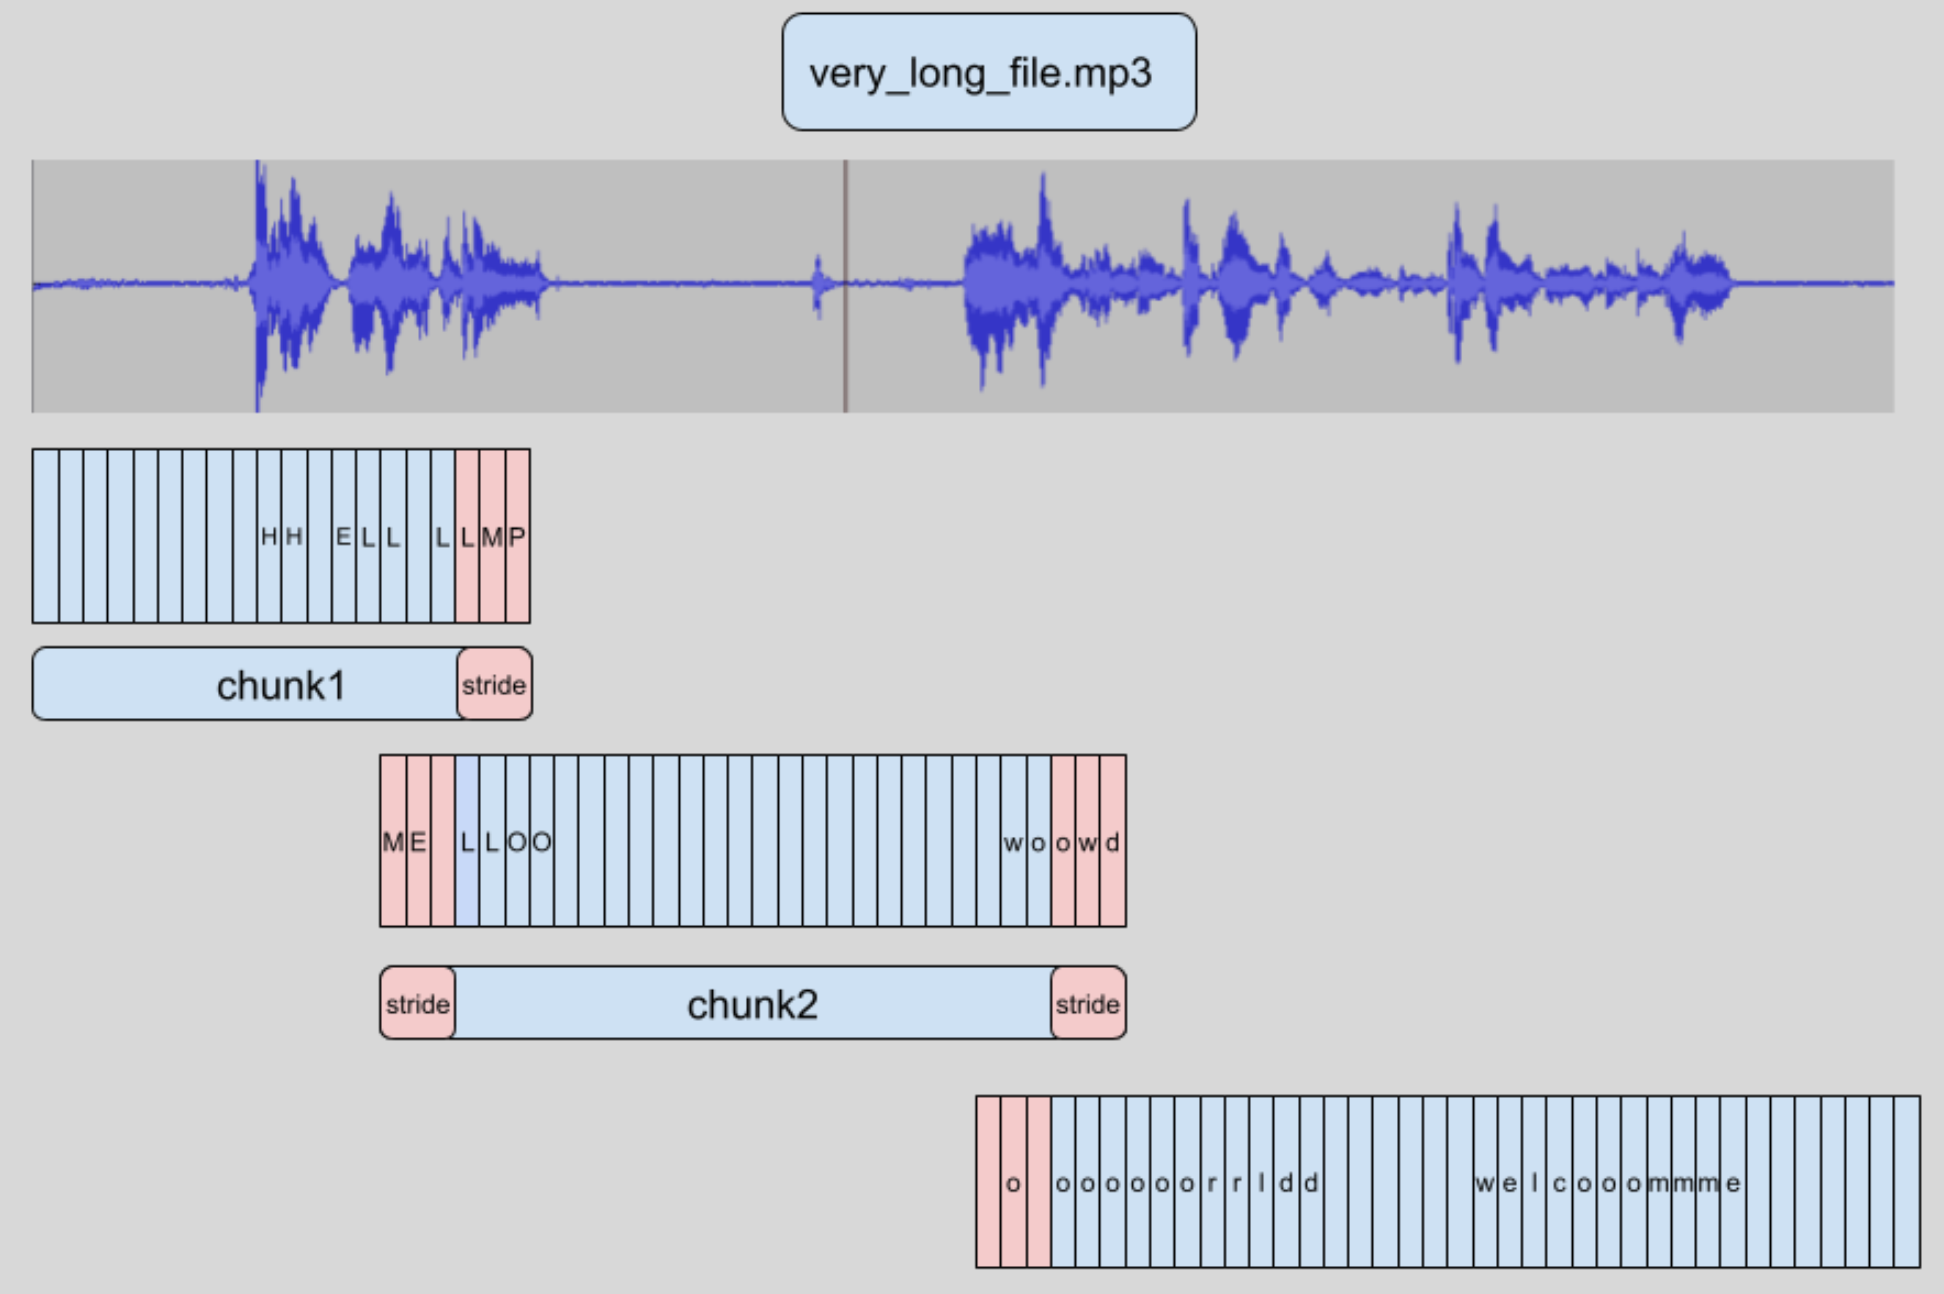


* The advantage of chunking is that it is not **sequential**.
  * we don’t need the result of chunk i to transcribe the subsequent chunk i+1.
  * The algorithm is entirely stateless, so we can even do all the chunks at the same time.
  * This allows us to batch the chunks and run them through the model in parallel, providing a large computational speed-up compared to transcribing them sequentially.

In [48]:
# chunk_length_s: controls the length of the chunked segments in seconds
# For Whisper, 30 second chunks are optimal

pipe(
    long_audio,
    # max_new_tokens=256,
    generate_kwargs={"task": "transcribe"},
    chunk_length_s=30,
    batch_size=8,
)

Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


{'text': ' y las almas buscando alguna livio, se revuelven ansiosas y hacen el mundo, que así resulta ser del dolor obra, el dolor o la nada, quien tenga corazón venga y escoja. Cuando calle el dolor, se oye a la muerte las alas tenebrosas batire en los profundos, cual si fuese en las solas del mar de la ilusión, en que los seres en rumbo bogan, donde se mesen, frágiles barquillas, las fugitivas formas, echar fuera la vida y acallar las domésticas cuestiones con el huero fragor de las políticas. No he casado a los hombres que se juntan y gritan. Ojas sus gritos son, que el viento lleva, mientras en silencio su dolor radica. El vivir con el hombre, pobre bestia, te ha dado a casa un anhelar oscuro que el lobo no conoce. Tal vez, cuando costabas la cabeza en mi regazo vagamente soñabas en ser hombre después de muerto. Ser hombre, pobre be. No sabe lo que busca y tú para él mi alma solo tienes esta palabra. Nunca. Adar voces vacías, pobrescillos se juntan y gritan y más gritan y sus penas

* Timestamps:
  * Whisper is also able to predict segment-level timestamps for the audio data.
  * These timestamps indicate the start and end time for a short passage of audio, and are particularly useful for aligning a transcription with the input audio.

In [49]:
# Set the argument return_timestamps=True
pipe(
    long_audio,
    # max_new_tokens=256,
    generate_kwargs={"task": "transcribe"},
    chunk_length_s=30,
    batch_size=8,
    return_timestamps=True,
)["chunks"]

Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


[{'timestamp': (0.0, 67.0),
  'text': ' Y las almas, buscando alguna livio, se revuelven ansiosas y hacen el mundo, que así resulta ser del dolor obra. El dolor o la nada, que entenga corazón venga y escoja. Cuando calle el dolor, se oye a la muerte las alas tenebrosas batire en los profundos, cual si fuese en las solas del mar de la ilusión, en que los seres sin rumbo bogan, donde se mesen, frágiles barquillas, las fugitivas formas, echar fuera la vida y acallar las domésticas cuestiones con el huero fragor de las políticas. No he casado a los hombres que se juntan y gritan. Ojas sus gritos son que el viento lleva mientras en silencio su dolor radica. El vivir con el hombre, pobre bestia, te ha dado a casa un anhelar oscuro que el lobo no conoce. Tal vez cuando costabas la cabeza en mi regazo vagamente soñabas en ser hombre después'},
 {'timestamp': (67.0, 75.0),
  'text': ' de muerto, ser hombre, pobre bebe, no sabe lo que busca y tú para él mi alma solo tienes'},
 {'timestamp': (75.

* Whisper splits on speech boundaries, not fixed time intervals. Even though each chunk is at most 30 seconds, Whisper tries to find a natural break point (pause, sentence end) so it doesn't cut a word in half.